# Machine Learning Showcase: Genre-Vorhersage mit Spotify-Daten

In diesem Notebook lernen wir, wie man mit Machine Learning das Genre eines Songs vorhersagen kann.

**Was wir lernen:**
- Wie man Daten für ML vorbereitet (Features vs. Zielvariable)
- Warum wir Trainings- und Testdaten trennen
- Wie ein Decision Tree funktioniert
- Wie wir die Qualität unseres Modells bewerten

## 1. Setup und Daten laden

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

# Helpers importieren
sys.path.append('src')
from src.helpers import load_dataset, filter_data
from src.helpers.ml import (
    prepare_ml_data, 
    split_data, 
    train_model,
    evaluate_model, 
    predict,
    plot_confusion_matrix,
    plot_feature_importance,
    plot_decision_tree
)

# Spotify-Daten laden
spotify = load_dataset('spotify')
print(f"Datensatz geladen: {spotify.shape[0]} Songs, {spotify.shape[1]} Spalten")
spotify.head()

Datensatz geladen: 18679 Songs, 21 Spalten


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 2. Daten filtern

Wir fokussieren uns auf 4 Genres, um das Problem einfacher zu machen. Mit zu vielen Genres wird die Vorhersage schwieriger.

In [21]:
# Welche Genres gibt es?
print("Verfügbare Genres:")
print(spotify['track_genre'].value_counts().head(20))

Verfügbare Genres:
track_genre
pop-film             740
chill                699
k-pop                583
hip-hop              508
deep-house           500
ambient              495
anime                479
british              475
emo                  440
grunge               424
acoustic             398
mandopop             384
piano                357
progressive-house    350
spanish              344
indian               335
alt-rock             335
garage               329
edm                  329
electronic           313
Name: count, dtype: int64


In [22]:
# 4 unterschiedliche Genres auswaehlen
selected_genres = ['pop-film', 'hip-hop', 'ambient', 'deep-house']

spotify_ml = filter_data(spotify, track_genre=selected_genres)
print(f"Gefiltert auf {len(spotify_ml)} Songs")
print(f"\nGenre-Verteilung:")
print(spotify_ml['track_genre'].value_counts())

Gefiltert auf 2243 Songs

Genre-Verteilung:
track_genre
pop-film      740
hip-hop       508
deep-house    500
ambient       495
Name: count, dtype: int64


## 3. Features und Zielvariable definieren

**Wichtige Konzepte:**
- **Features (X)**: Die Eigenschaften, die wir dem Modell geben (z.B. danceability, energy)
- **Zielvariable (y)**: Was wir vorhersagen wollen (hier: track_genre)

Das Modell lernt Muster in den Features, um die Zielvariable vorherzusagen.

In [23]:
# Features auswählen - das sind die Audio-Eigenschaften der Songs
feature_columns = ['danceability', 'energy', 'acousticness', 'valence', 
                   'tempo', 'speechiness', 'instrumentalness', 'liveness']

# Daten vorbereiten
X, y = prepare_ml_data(
    spotify_ml, 
    target='track_genre',
    features=feature_columns
)

print(f"\nFeatures (X): {X.shape}")
print(f"Zielvariable (y): {y.shape}")

Daten vorbereitet: 2243 Datensätze, 8 Features, Ziel: 'track_genre'

Features (X): (2243, 8)
Zielvariable (y): (2243,)


In [24]:
# Schauen wir uns die Features an
print("Beispiel-Daten (erste 5 Songs):")
X.head()

Beispiel-Daten (erste 5 Songs):


,danceability,energy,acousticness,valence,tempo,speechiness,instrumentalness,liveness
875,0.454,0.400,0.1390,0.327,93.719,0.0265,0.846,0.137
876,0.521,0.298,0.7540,0.232,80.388,0.0260,0.460,0.110
877,0.370,0.467,0.0205,0.182,94.485,0.0273,0.572,0.109
878,0.406,0.399,0.7560,0.163,142.830,0.0278,0.678,0.112
879,0.450,0.511,0.3530,0.115,96.563,0.0276,0.766,0.139


## 4. Train/Test Split

**Warum teilen wir die Daten?**

Stell dir vor, du lernst für eine Prüfung:
- **Trainingsdaten** = Die Übungsaufgaben, mit denen du lernst
- **Testdaten** = Die Prüfung selbst (neue, ungesehene Aufgaben)

Wenn du nur die Übungsaufgaben auswendig lernst, weisst du nicht, ob du das Thema wirklich verstanden hast. Genauso beim Modell: Wir testen es mit Daten, die es noch nie gesehen hat.

In [25]:
# Daten aufteilen: 80% Training, 20% Test
X_train, X_test, y_train, y_test = split_data(X, y, test_size=0.2)

print(f"\nTrainingsdaten: {len(X_train)} Songs")
print(f"Testdaten: {len(X_test)} Songs")

Daten aufgeteilt: Training: 1794 (80%), Test: 449 (20%)

Trainingsdaten: 1794 Songs
Testdaten: 449 Songs


## 5. Modell trainieren

Wir verwenden einen **Decision Tree** (Entscheidungsbaum).

**Wie funktioniert ein Decision Tree?**
- Der Baum stellt Fragen wie: "Ist die danceability > 0.7?"
- Je nach Antwort geht er einen anderen Zweig entlang
- Am Ende landet er bei einer Vorhersage (z.B. "hip-hop")

**max_depth** begrenzt, wie tief der Baum werden darf. Das verhindert "Overfitting" (zu genaues Auswendiglernen der Trainingsdaten).

In [38]:
# Decision Tree trainieren
model = train_model(X_train, y_train, model_type='decision_tree', max_depth=8)

Modell trainiert: Decision Tree (max_depth=8)


## 6. Modell bewerten

Jetzt testen wir, wie gut unser Modell ist - mit den Testdaten, die es noch nie gesehen hat!

In [39]:
# Modell auf Testdaten bewerten
results = evaluate_model(model, X_test, y_test)

Genauigkeit: 68.8% (68.8% der Songs wurden richtig klassifiziert)

Klassifikationsbericht:
              precision    recall  f1-score   support

     ambient       0.88      0.88      0.88        99
  deep-house       0.71      0.70      0.70       100
     hip-hop       0.55      0.52      0.54       102
    pop-film       0.64      0.67      0.65       148

    accuracy                           0.69       449
   macro avg       0.69      0.69      0.69       449
weighted avg       0.69      0.69      0.69       449



### Was bedeutet die Genauigkeit?

- Bei 4 Genres waere **zufälliges Raten** etwa 25% genau
- Eine Genauigkeit von **50-70%** zeigt, dass das Modell etwas gelernt hat
- **80%+** wäre sehr gut für dieses Problem

## 7. Konfusionsmatrix visualisieren

Die **Konfusionsmatrix** zeigt, welche Genres wie oft verwechselt werden:
- Diagonale (von oben links nach unten rechts) = Richtige Vorhersagen
- Ausserhalb der Diagonale = Fehler

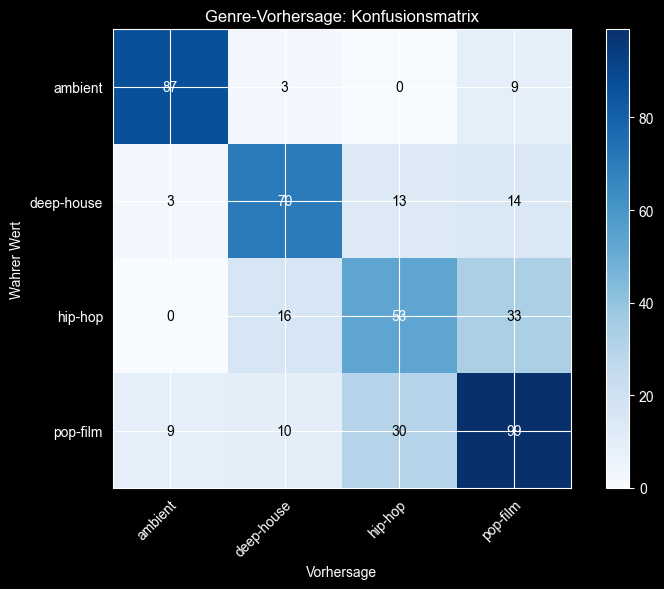

In [40]:
# Konfusionsmatrix anzeigen
plot_confusion_matrix(y_test, results['predictions'], title='Genre-Vorhersage: Konfusionsmatrix')

## 8. Feature-Wichtigkeit

Welche Audio-Eigenschaften sind am wichtigsten für die Genre-Vorhersage?

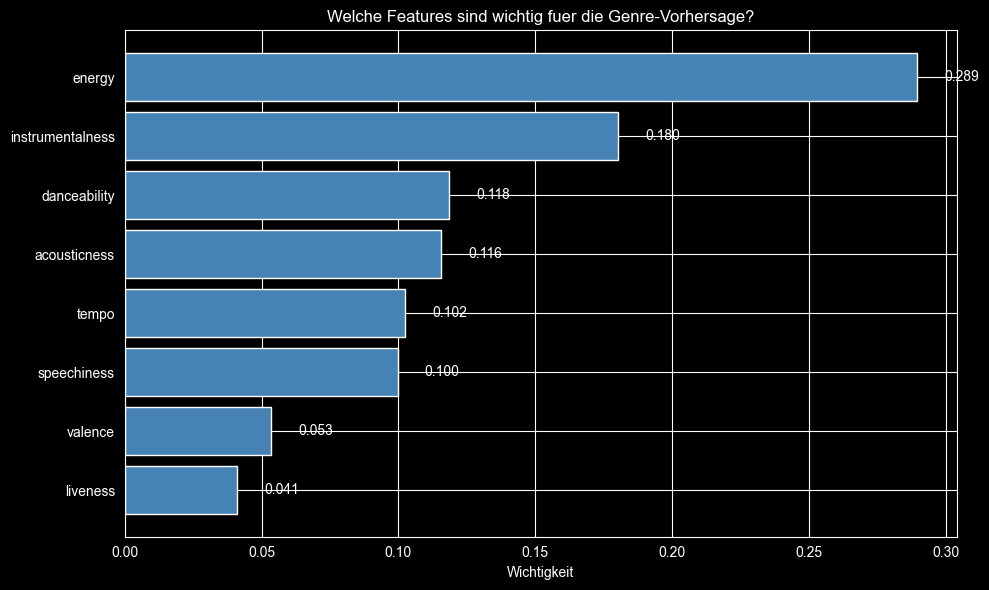


Top 8 wichtigste Features:
  energy: 0.289
  instrumentalness: 0.180
  danceability: 0.118
  acousticness: 0.116
  tempo: 0.102
  speechiness: 0.100
  valence: 0.053
  liveness: 0.041


In [41]:
# Feature-Wichtigkeit visualisieren
importance_df = plot_feature_importance(
    model, 
    feature_columns,
    title='Welche Features sind wichtig fuer die Genre-Vorhersage?'
)

## 9. Decision Tree visualisieren

Schauen wir uns an, wie der Baum Entscheidungen trifft:

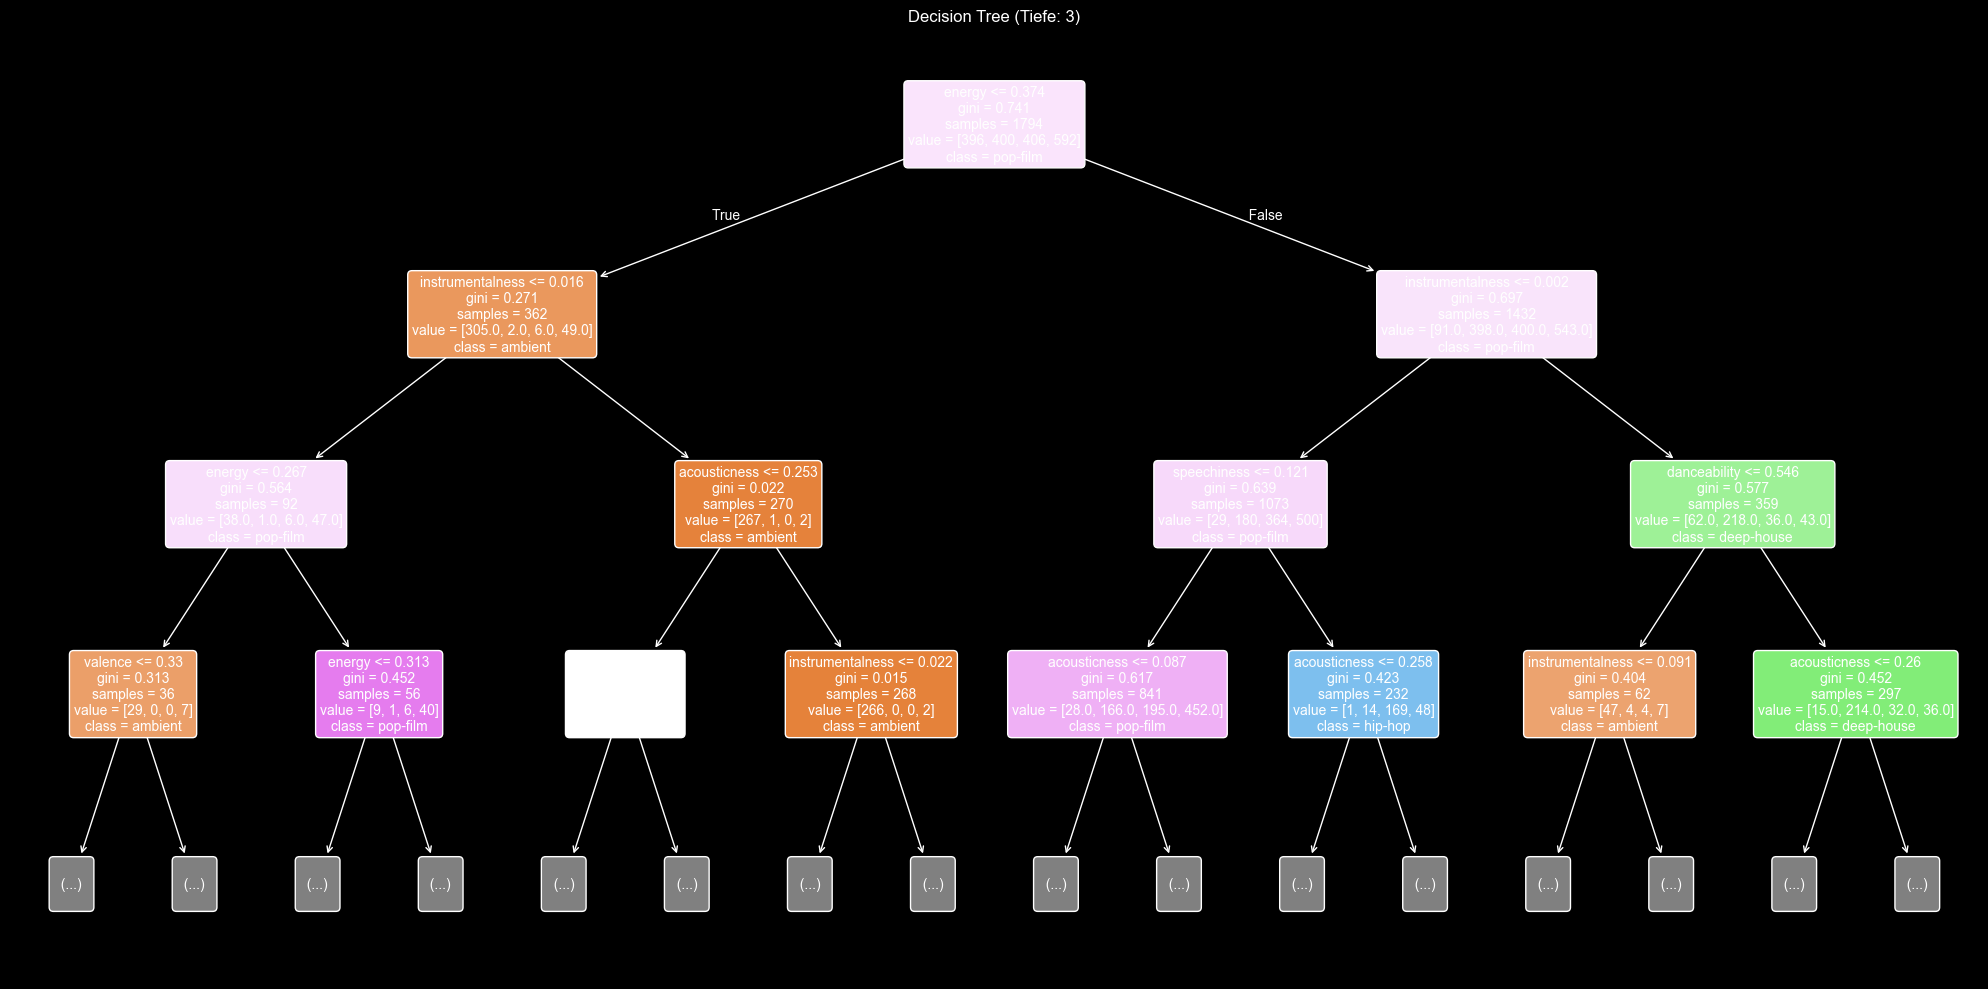

Baum-Visualisierung (zeigt Tiefe 3 von 8 Ebenen)


In [42]:
# Decision Tree visualisieren (nur die ersten 3 Ebenen)
plot_decision_tree(model, feature_columns, max_depth=3)

## 10. Vorhersagen für neue Daten

Jetzt koennen wir das Modell nutzen, um für beliebige Songs das Genre vorherzusagen:

In [43]:
# 5 zufällige Songs auswaehlen
sample_songs = spotify_ml.sample(5, random_state=123)

# Vorhersagen machen
predictions = predict(model, sample_songs, features=feature_columns)

# Ergebnisse anzeigen
result_df = sample_songs[['track_name', 'artists', 'track_genre']].copy()
result_df['vorhersage'] = predictions.values
result_df['richtig'] = result_df['track_genre'] == result_df['vorhersage']

print("Vorhersagen fuer 5 Songs:")
result_df

Vorhersagen gemacht für 5 Datensätze.
Vorhersagen fuer 5 Songs:


,track_name,artists,track_genre,vorhersage,richtig
1193,Rainbow Connection,Sleeping At Last,ambient,ambient,True
1302,Bloodflow,Grandbrothers,ambient,ambient,True
4850,My Humps,Joshwa;Lee Foss,deep-house,deep-house,True
1167,Restless,Abel Korzeniowski,ambient,ambient,True
908,Dheera Dheera,Mohan;Ananya Bhat;Santhosh Venky;Sachin Basrur...,ambient,pop-film,False


## 11. Experiment: Random Forest

Ein **Random Forest** ist eine Sammlung von vielen Decision Trees, die zusammen abstimmen. Das ist oft genauer als ein einzelner Baum.

In [44]:
# Random Forest trainieren
rf_model = train_model(X_train, y_train, model_type='random_forest', max_depth=5)

# Bewerten
rf_results = evaluate_model(rf_model, X_test, y_test)

Modell trainiert: Random Forest (max_depth=5)
Genauigkeit: 75.5% (75.5% der Songs wurden richtig klassifiziert)

Klassifikationsbericht:
              precision    recall  f1-score   support

     ambient       0.93      0.92      0.92        99
  deep-house       0.80      0.76      0.78       100
     hip-hop       0.68      0.53      0.60       102
    pop-film       0.67      0.80      0.73       148

    accuracy                           0.76       449
   macro avg       0.77      0.75      0.76       449
weighted avg       0.76      0.76      0.75       449



In [45]:
# Vergleich: Decision Tree vs Random Forest
print("\n" + "="*50)
print("VERGLEICH DER MODELLE")
print("="*50)
print(f"Decision Tree Genauigkeit: {results['accuracy']:.1%}")
print(f"Random Forest Genauigkeit: {rf_results['accuracy']:.1%}")
print("="*50)


VERGLEICH DER MODELLE
Decision Tree Genauigkeit: 68.8%
Random Forest Genauigkeit: 75.5%


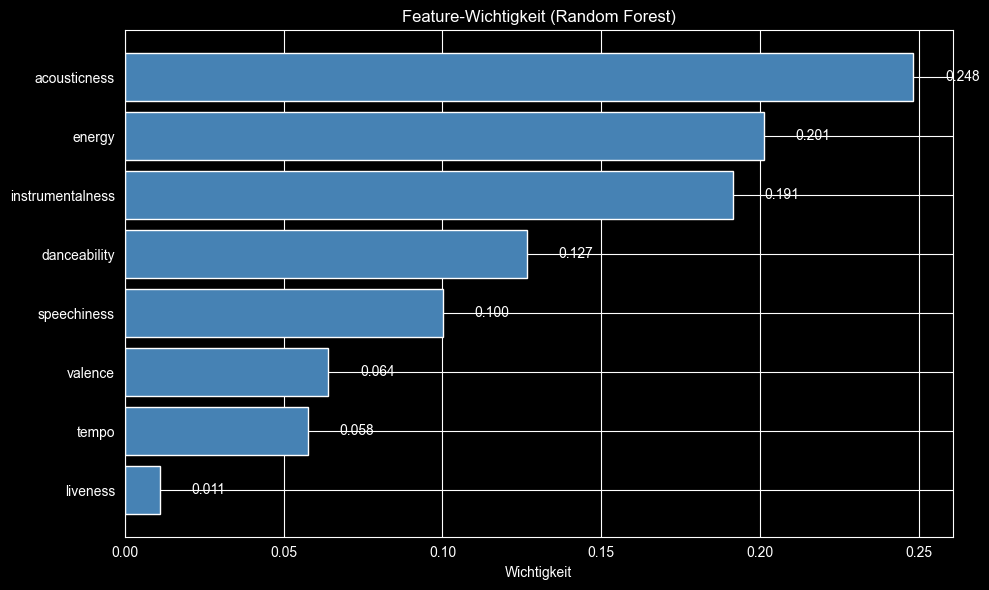


Top 8 wichtigste Features:
  acousticness: 0.248
  energy: 0.201
  instrumentalness: 0.191
  danceability: 0.127
  speechiness: 0.100
  valence: 0.064
  tempo: 0.058
  liveness: 0.011


In [46]:
# Feature-Wichtigkeit des Random Forest
rf_importance = plot_feature_importance(
    rf_model, 
    feature_columns,
    title='Feature-Wichtigkeit (Random Forest)'
)

## 12. Experiment: Mehr Genres

Was passiert, wenn wir mehr Genres hinzufügen? Die Aufgabe wird schwieriger!

In [47]:
# 8 Genres auswählen
more_genres = ['pop-film', 'hip-hop', 'ambient', 'deep-house', 'rock', 'classical', 'jazz', 'electronic']

spotify_8genres = filter_data(spotify, track_genre=more_genres)
print(f"Datensatz mit 8 Genres: {len(spotify_8genres)} Songs")
print(spotify_8genres['track_genre'].value_counts())

Datensatz mit 8 Genres: 2701 Songs
track_genre
pop-film      740
hip-hop       508
deep-house    500
ambient       495
electronic    313
rock           52
jazz           51
classical      42
Name: count, dtype: int64


In [48]:
# ML Pipeline für 8 Genres
X8, y8 = prepare_ml_data(spotify_8genres, target='track_genre', features=feature_columns)
X8_train, X8_test, y8_train, y8_test = split_data(X8, y8)

model_8genres = train_model(X8_train, y8_train, model_type='random_forest', max_depth=7)
results_8genres = evaluate_model(model_8genres, X8_test, y8_test, show_details=False)

Daten vorbereitet: 2701 Datensätze, 8 Features, Ziel: 'track_genre'
Daten aufgeteilt: Training: 2160 (80%), Test: 541 (20%)
Modell trainiert: Random Forest (max_depth=7)
Genauigkeit: 64.9% (64.9% der Songs wurden richtig klassifiziert)


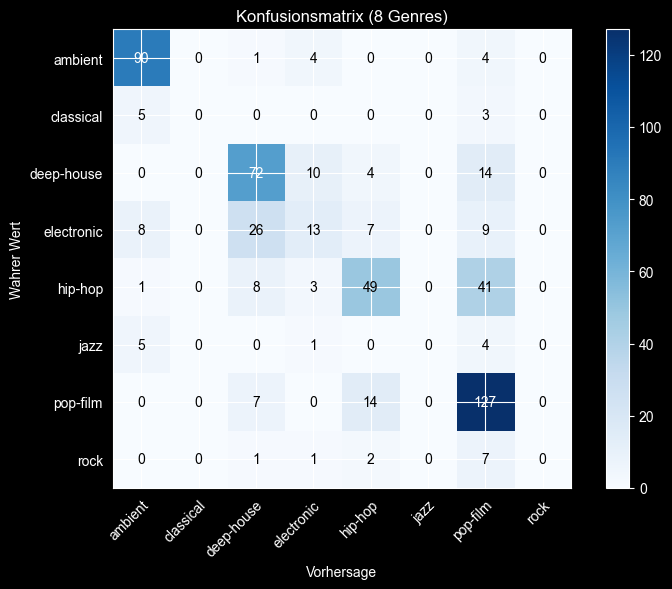

In [49]:
# Konfusionsmatrix für 8 Genres
plot_confusion_matrix(y8_test, results_8genres['predictions'], 
                      title='Konfusionsmatrix (8 Genres)')

## Zusammenfassung

**Was wir gelernt haben:**

1. **Daten vorbereiten**: Features (X) und Zielvariable (y) trennen
2. **Train/Test Split**: Daten aufteilen, um das Modell fair zu testen
3. **Modell trainieren**: Decision Tree oder Random Forest
4. **Bewerten**: Genauigkeit und Konfusionsmatrix analysieren
5. **Interpretieren**: Feature-Wichtigkeit zeigt, was das Modell gelernt hat

**Naechste Schritte zum Ausprobieren:**
- Andere Genres auswaehlen
- Andere Features verwenden
- max_depth veraendern
- Mit den Olympics- oder Movies-Daten experimentieren